In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pickle

train_df = pd.read_csv('../data/processed_train.csv')
test_df  = pd.read_csv('../data/processed_test.csv')

USEFUL_SENSORS = ['s2','s3','s4','s7','s8','s9','s11',
                  's12','s13','s14','s15','s17','s20','s21']

WINDOW_SIZE = 30

print("Train shape:", train_df.shape)
print("Test shape: ", test_df.shape)

Train shape: (20631, 20)
Test shape:  (13096, 19)


In [3]:
# Looking at engine 1's first 35 cycles to understand what we're slicing
engine_1 = train_df[train_df['engine_id'] == 1].reset_index(drop=True)

print("Engine 1 first 35 cycles, sensor s2:")
print(engine_1[['engine_id','cycle','s2','RUL']].head(35).to_string())

Engine 1 first 35 cycles, sensor s2:
    engine_id  cycle        s2  RUL
0           1      1  0.183735  125
1           1      2  0.283133  125
2           1      3  0.343373  125
3           1      4  0.343373  125
4           1      5  0.349398  125
5           1      6  0.268072  125
6           1      7  0.382530  125
7           1      8  0.406627  125
8           1      9  0.274096  125
9           1     10  0.150602  125
10          1     11  0.322289  125
11          1     12  0.256024  125
12          1     13  0.560241  125
13          1     14  0.343373  125
14          1     15  0.367470  125
15          1     16  0.277108  125
16          1     17  0.412651  125
17          1     18  0.424699  125
18          1     19  0.174699  125
19          1     20  0.551205  125
20          1     21  0.349398  125
21          1     22  0.469880  125
22          1     23  0.280120  125
23          1     24  0.352410  125
24          1     25  0.469880  125
25          1     26  0.286

In [4]:
def create_windows(df, window_size, sensors):
    X, y = [], []
    
    for engine_id in df['engine_id'].unique():
        # Get all cycles for this engine, sorted
        engine_data = df[df['engine_id'] == engine_id].sort_values('cycle')
        
        sensor_values = engine_data[sensors].values
        rul_values    = engine_data['RUL'].values
        
        # Slide the window across every valid position
        for i in range(len(engine_data) - window_size + 1):
            window  = sensor_values[i : i + window_size]  # shape: (30, 14)
            label   = rul_values[i + window_size - 1]     # RUL at the last cycle in window
            
            X.append(window)
            y.append(label)
    
    return np.array(X), np.array(y)

X_train, y_train = create_windows(train_df, WINDOW_SIZE, USEFUL_SENSORS)

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)

X_train shape: (17731, 30, 14)
y_train shape: (17731,)


In [5]:
# How many samples did we lose per engine?
total_raw_rows  = len(train_df)
total_windows   = len(X_train)
lost            = total_raw_rows - total_windows

print(f"Raw rows:      {total_raw_rows}")
print(f"Windows:       {total_windows}")
print(f"Rows lost:     {lost}")
print(f"Why: first {WINDOW_SIZE-1} cycles of each engine can't form a full window")
print(f"Number of engines: {train_df['engine_id'].nunique()}")
print(f"Lost per engine: ~{lost // train_df['engine_id'].nunique()} rows")

Raw rows:      20631
Windows:       17731
Rows lost:     2900
Why: first 29 cycles of each engine can't form a full window
Number of engines: 100
Lost per engine: ~29 rows


In [6]:
# For test data we only want the LAST window of each engine
# That's the prediction point — the most recent 30 cycles before cutoff

def create_test_windows(df, window_size, sensors):
    X = []
    
    for engine_id in df['engine_id'].unique():
        engine_data = df[df['engine_id'] == engine_id].sort_values('cycle')
        
        # Only take the last window
        if len(engine_data) >= window_size:
            window = engine_data[sensors].values[-window_size:]
        else:
            # Engine has fewer cycles than window size — pad with zeros at the start
            window = engine_data[sensors].values
            pad    = np.zeros((window_size - len(engine_data), len(sensors)))
            window = np.vstack([pad, window])
        
        X.append(window)
    
    return np.array(X)

X_test = create_test_windows(test_df, WINDOW_SIZE, USEFUL_SENSORS)

print("X_test shape:", X_test.shape)

X_test shape: (100, 30, 14)


In [7]:
test_labels = pd.read_csv('../data/test_labels.csv')
y_test = test_labels['true_RUL'].values

print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

X_test shape: (100, 30, 14)
y_test shape: (100,)


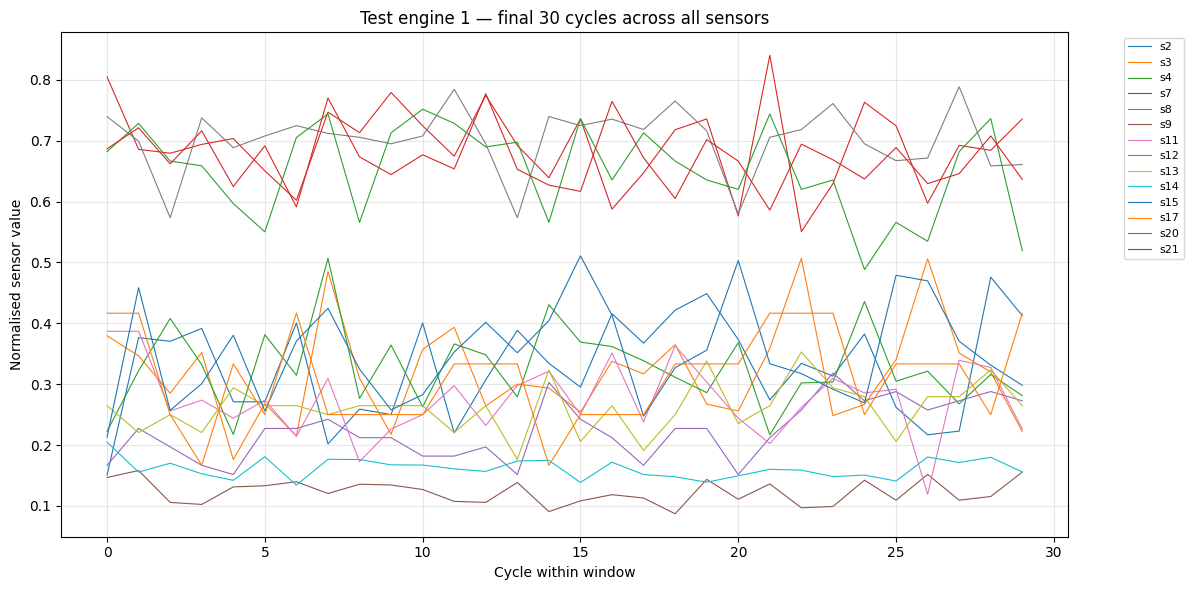

In [8]:
# Look at the last window of test engine 1
sample_window = X_test[0]  # shape (30, 14)

plt.figure(figsize=(12, 6))
for i, sensor in enumerate(USEFUL_SENSORS):
    plt.plot(sample_window[:, i], label=sensor, linewidth=0.8)

plt.xlabel('Cycle within window')
plt.ylabel('Normalised sensor value')
plt.title('Test engine 1 — final 30 cycles across all sensors')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [9]:
np.save('../data/X_train.npy', X_train)
np.save('../data/y_train.npy', y_train)
np.save('../data/X_test.npy',  X_test)
np.save('../data/y_test.npy',  y_test)

print("Shapes saved:")
print(f"  X_train: {X_train.shape}")
print(f"  y_train: {y_train.shape}")
print(f"  X_test:  {X_test.shape}")
print(f"  y_test:  {y_test.shape}")

Shapes saved:
  X_train: (17731, 30, 14)
  y_train: (17731,)
  X_test:  (100, 30, 14)
  y_test:  (100,)
